# MTN Nigeria Customer Churn: EDA & Data Cleaning

Author: Tobi Bolu | [LinkedIn](https://www.linkedin.com/in/tobibolu/) | [GitHub](https://github.com/tobibolu)

This notebook explores the MTN Nigeria customer churn dataset, assesses data quality, and prepares features for modeling.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os
import warnings
from scipy import stats
import kagglehub

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120})
np.random.seed(42)


/Users/tobibolu/opt/anaconda3/lib/python3.8/site-packages/scipy/__init__.py:138: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.3)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion} is required for this version of "


## Step 1: Load & Explore Data

I'm downloading the MTN Nigeria customer churn dataset from Kaggle and performing initial discovery.

In [2]:
# Download dataset
print("Downloading MTN Nigeria customer churn dataset...")
path = kagglehub.dataset_download("oluwademiladeadeniyi/mtn-nigeria-customer-churn")
print(f"Dataset path: {path}")

# Load the data
csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
df = pd.read_csv(os.path.join(path, csv_file))

print(f"\nDataset Shape: {df.shape}")
print(f"\nColumn Names & Types:")
print(df.dtypes)
print(f"\nFirst 5 rows:")
print(df.head())
print(f"\nBasic Statistics:")
print(df.describe())

Dataset path: /Users/tobibolu/.cache/kagglehub/datasets/oluwademiladeadeniyi/mtn-nigeria-customer-churn/versions/4

Dataset Shape: (974, 17)

Column Names & Types:
Customer ID                   object
Full Name                     object
Date of Purchase              object
Age                            int64
State                         object
MTN Device                    object
Gender                        object
Satisfaction Rate              int64
Customer Review               object
Customer Tenure in months      int64
Subscription Plan             object
Unit Price                     int64
Number of Times Purchased      int64
Total Revenue                  int64
Data Usage                   float64
Customer Churn Status         object
Reasons for Churn             object
dtype: object

First 5 rows:
  Customer ID     Full Name Date of Purchase  Age        State  \
0    CUST0001   Ngozi Berry           Jan-25   27        Kwara   
1    CUST0002  Zainab Baker           Mar-25  

## Step 2: Adaptive Column Mapping

I'm identifying key columns based on naming patterns. This approach ensures the notebook works even if exact column names differ.

In [3]:
# Setting up adaptive column mapping
all_cols_lower = [c.lower() for c in df.columns]

# Helper function to match column names by pattern
def find_column(patterns):
    """Find first column matching any of the patterns (case-insensitive)."""
    if isinstance(patterns, str):
        patterns = [patterns]
    for pattern in patterns:
        for col in all_cols_lower:
            if pattern in col:
                return [c for c in df.columns if c.lower() == col][0]
    return None

# Identifying key columns in the dataset
churn_col = find_column(['churn', 'churned', 'attrition', 'left', 'exited'])
tenure_col = find_column(['tenure', 'months', 'duration'])
age_col = find_column(['age'])
gender_col = find_column(['gender', 'sex'])
location_col = find_column(['state', 'location', 'region', 'city'])
usage_cols = [c for c in df.columns if any(p in c.lower() for p in ['usage', 'minutes', 'calls', 'data', 'sms'])]
charge_cols = [c for c in df.columns if any(p in c.lower() for p in ['charge', 'bill', 'payment', 'amount', 'balance', 'revenue', 'arpu'])]
plan_col = find_column(['plan', 'contract', 'service', 'subscription'])
complaint_col = find_column(['complaint', 'support', 'ticket'])

# Printing the discovered mapping for verification
print("DISCOVERED COLUMN MAPPING:")
print(f"  Churn Target: {churn_col}")
print(f"  Tenure: {tenure_col}")
print(f"  Age: {age_col}")
print(f"  Gender: {gender_col}")
print(f"  Location: {location_col}")
print(f"  Usage Features: {usage_cols}")
print(f"  Charge Features: {charge_cols}")
print(f"  Plan/Service: {plan_col}")
print(f"  Complaints: {complaint_col}")
print(f"\nAll columns in dataset:")
print(list(df.columns))

DISCOVERED COLUMN MAPPING:
  Churn Target: Customer Churn Status
  Tenure: Customer Tenure in months
  Age: Age
  Gender: Gender
  Location: State
  Usage Features: ['Data Usage']
  Charge Features: ['Total Revenue']
  Plan/Service: Subscription Plan
  Complaints: None

All columns in dataset:
['Customer ID', 'Full Name', 'Date of Purchase', 'Age', 'State', 'MTN Device', 'Gender', 'Satisfaction Rate', 'Customer Review', 'Customer Tenure in months', 'Subscription Plan', 'Unit Price', 'Number of Times Purchased', 'Total Revenue', 'Data Usage', 'Customer Churn Status', 'Reasons for Churn']


## Step 3: Data Quality Assessment

I'm checking for missing values, duplicates, and data type issues.

In [4]:
# Checking for missing values
print("MISSING VALUES:")
missing = df.isnull().sum()
if missing.sum() > 0:
    print(missing[missing > 0])
    print(f"\nMissing %:")
    print((missing[missing > 0] / len(df) * 100).round(2))
else:
    print("No missing values detected.")

# Checking for duplicates
print(f"\nDUPLICATES: {df.duplicated().sum()} rows")

# Checking data types
print(f"\nDATA TYPE DISTRIBUTION:")
print(df.dtypes.value_counts())

# Identifying numerical and categorical columns
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"\nNumerical columns ({len(numerical_cols)}): {numerical_cols[:5]}...")
print(f"Categorical columns ({len(categorical_cols)}): {categorical_cols[:5]}...")

MISSING VALUES:
Reasons for Churn    690
dtype: int64

Missing %:
Reasons for Churn    70.84
dtype: float64

DUPLICATES: 0 rows

DATA TYPE DISTRIBUTION:
object     10
int64       6
float64     1
Name: count, dtype: int64

Numerical columns (7): ['Age', 'Satisfaction Rate', 'Customer Tenure in months', 'Unit Price', 'Number of Times Purchased']...
Categorical columns (10): ['Customer ID', 'Full Name', 'Date of Purchase', 'State', 'MTN Device']...


## Step 4: Statistical Profiling

I'm examining the distribution of key variables.

In [5]:
# Churn distribution breakdown
if churn_col:
    print(f"CHURN DISTRIBUTION ({churn_col}):")
    print(df[churn_col].value_counts())
    print(f"\nChurn Rate: {(df[churn_col].map({'Yes': 1, 'No': 0}).mean() * 100):.2f}%")
else:
    print("WARNING: Could not identify churn column")

# Numerical features summary
if numerical_cols:
    print(f"\nNUMERICAL FEATURES SUMMARY:")
    print(df[numerical_cols].describe().round(2))

# Categorical features summary
if categorical_cols:
    print(f"\nCATEGORICAL FEATURES (sample):")
    for col in categorical_cols[:3]:
        print(f"\n{col}:")
        print(df[col].value_counts().head())

CHURN DISTRIBUTION (Customer Churn Status):
Customer Churn Status
No     690
Yes    284
Name: count, dtype: int64

Churn Rate: 29.16%

NUMERICAL FEATURES SUMMARY:
          Age  Satisfaction Rate  Customer Tenure in months  Unit Price  \
count  974.00             974.00                     974.00      974.00   
mean    48.04               2.95                      31.42    19196.66   
std     17.76               1.38                      17.19    25586.73   
min     16.00               1.00                       1.00      350.00   
25%     32.00               2.00                      17.00     5500.00   
50%     49.00               3.00                      31.00    14500.00   
75%     63.75               4.00                      47.00    24000.00   
max     80.00               5.00                      60.00   150000.00   

       Number of Times Purchased  Total Revenue  Data Usage  
count                     974.00         974.00      974.00  
mean                       10.56     

## Step 5: Churn Overview

I'm visualizing the churn distribution to understand the baseline.

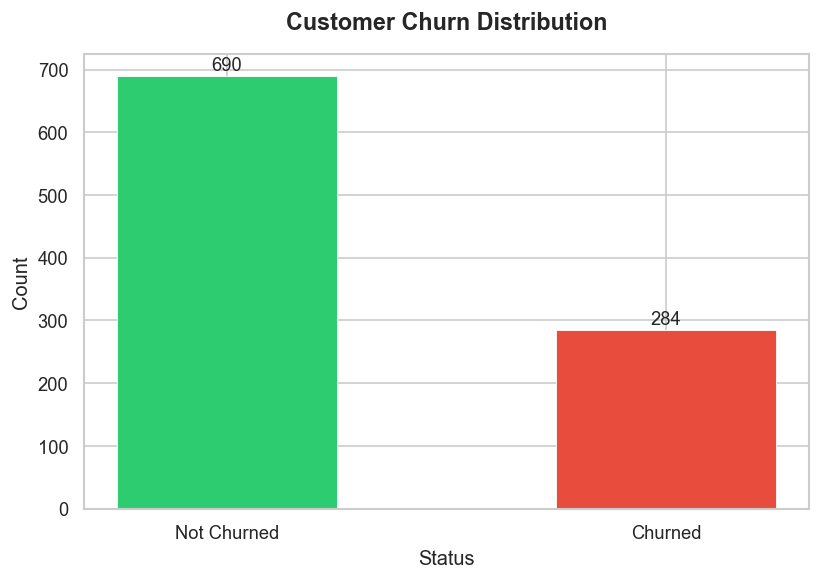

Overall Churn Rate: 29.16%


In [6]:
if churn_col:
    churn_counts = df[churn_col].value_counts()
    fig, ax = plt.subplots(figsize=(7, 5))
    bars = ax.bar(['Not Churned', 'Churned'],
                  [churn_counts.iloc[0], churn_counts.iloc[1]],
                  color=['#2ecc71', '#e74c3c'], edgecolor='white', linewidth=0.5, width=0.5)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 3,
                f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=11)
    ax.set_title('Customer Churn Distribution', fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Status')
    ax.set_ylabel('Count')
    plt.tight_layout()
    plt.show()

    churn_rate = df[churn_col].map({'Yes': 1, 'No': 0}).mean()
    print(f"Overall Churn Rate: {churn_rate*100:.2f}%")


## Step 6: Numerical Feature Distributions

I'm examining distributions of key continuous variables.

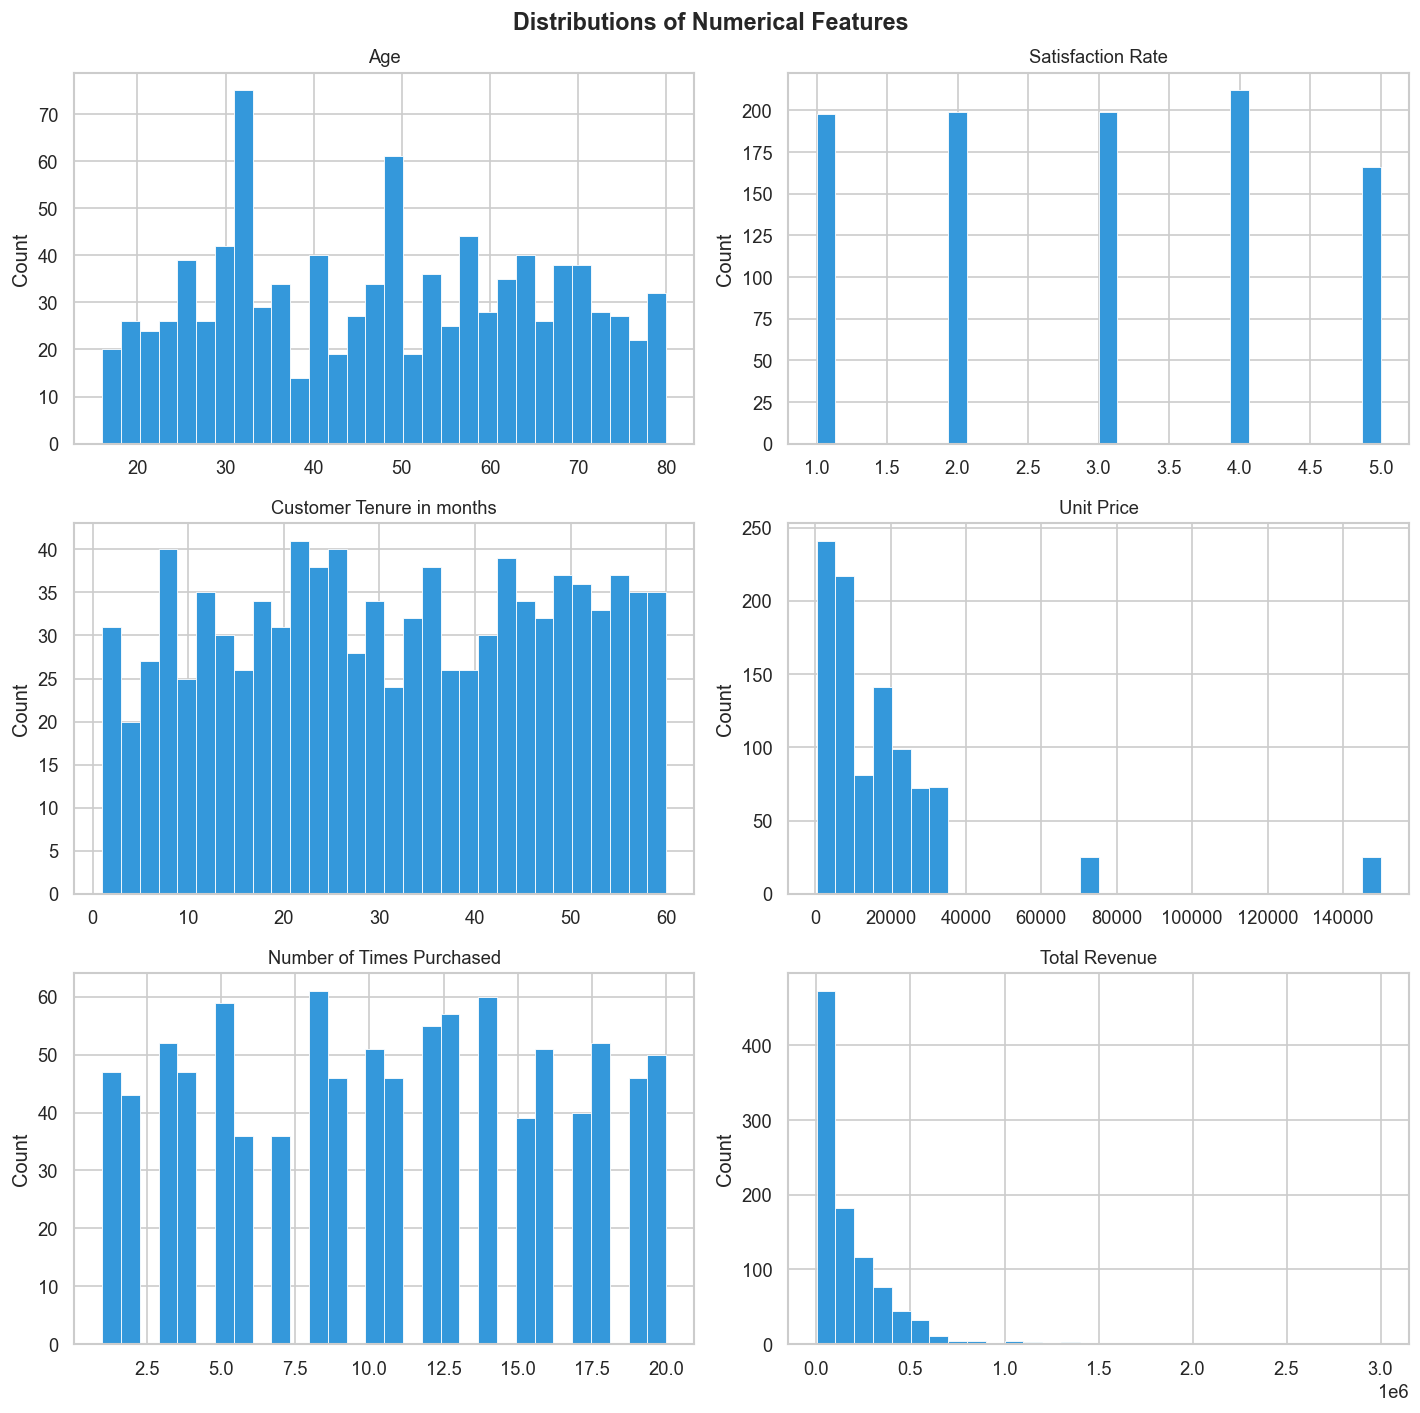

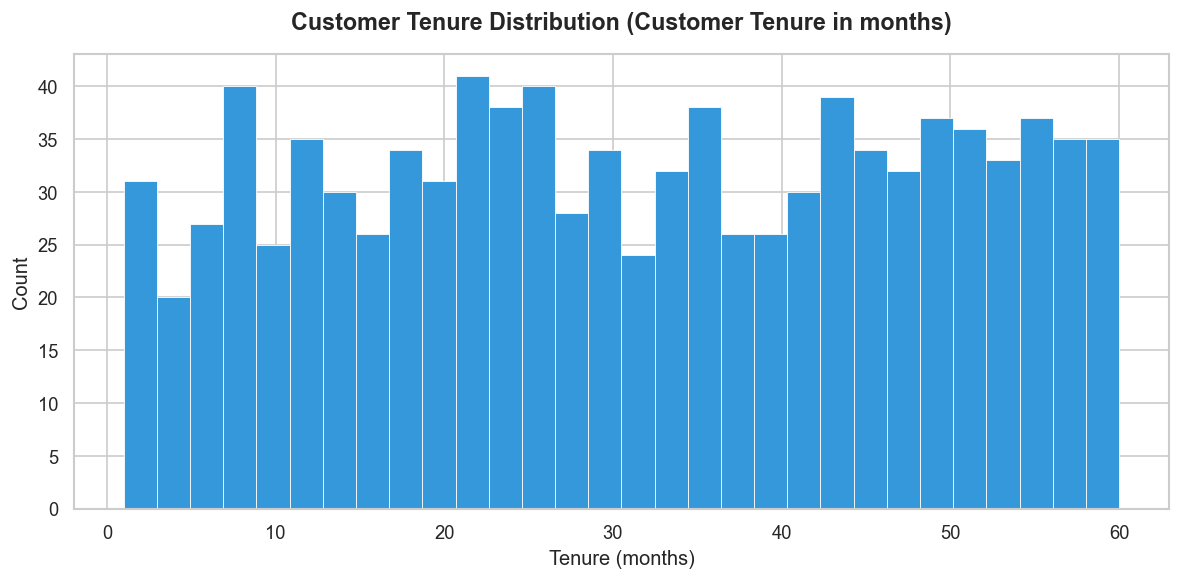

In [7]:
# Visualizing distributions of key numerical features
num_to_plot = numerical_cols[:6]

if num_to_plot:
    n_cols = 2
    n_rows = (len(num_to_plot) + 1) // 2
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
    axes = axes.flatten()
    for idx, col in enumerate(num_to_plot):
        axes[idx].hist(df[col].dropna(), bins=30, color='#3498db', edgecolor='white', linewidth=0.5)
        axes[idx].set_title(col, fontsize=11)
        axes[idx].set_ylabel('Count')
    for idx in range(len(num_to_plot), len(axes)):
        axes[idx].set_visible(False)
    fig.suptitle('Distributions of Numerical Features', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

if tenure_col and tenure_col in df.columns:
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.hist(df[tenure_col].dropna(), bins=30, color='#3498db', edgecolor='white', linewidth=0.5)
    ax.set_title(f'Customer Tenure Distribution ({tenure_col})', fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Tenure (months)')
    ax.set_ylabel('Count')
    plt.tight_layout()
    plt.show()


## Step 7: Churn Patterns by Key Features

I'm analyzing how churn varies across customer segments.

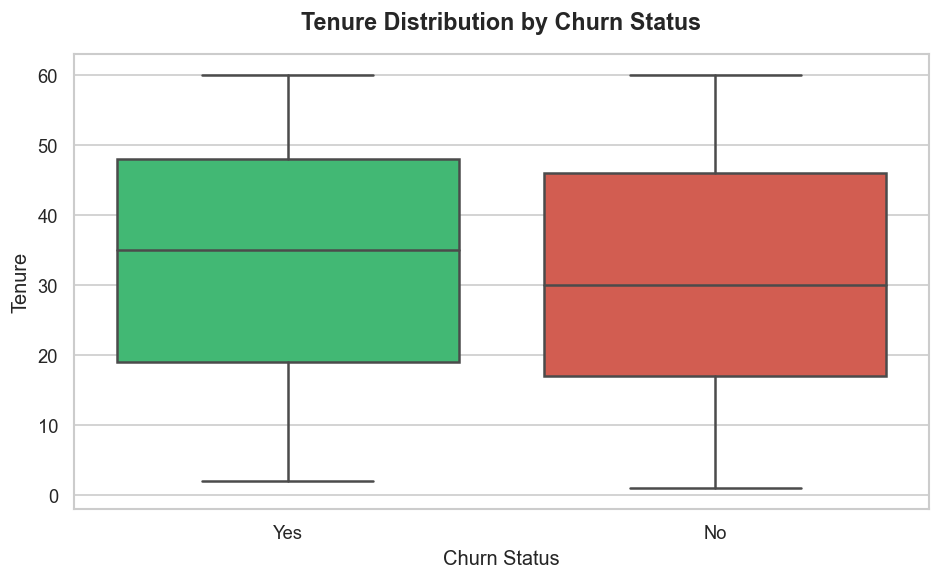

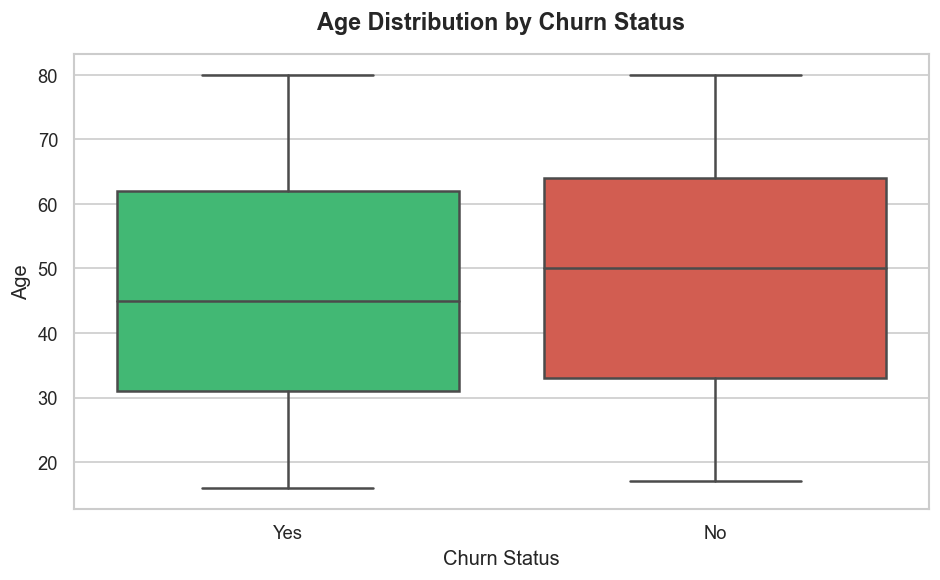

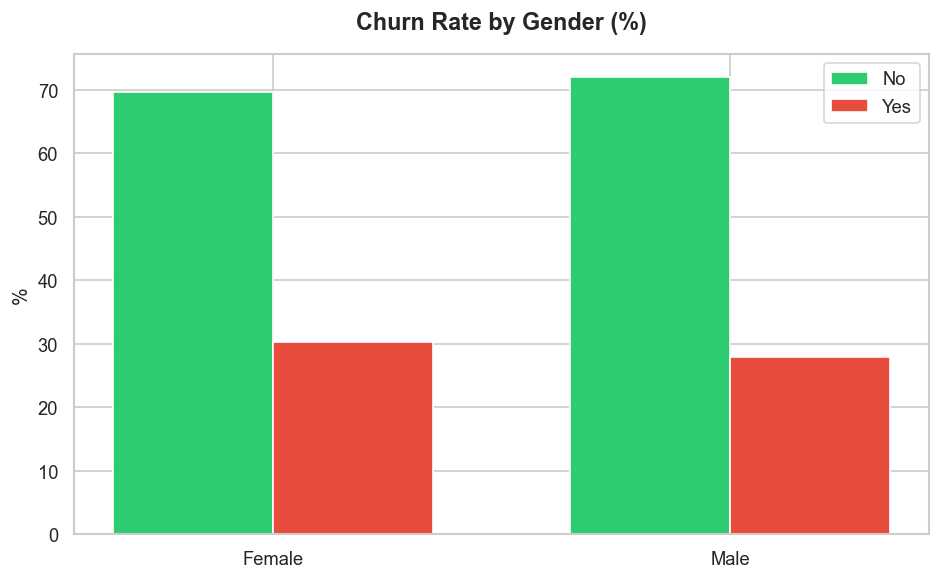

In [8]:
if churn_col and tenure_col and tenure_col in df.columns:
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.boxplot(data=df, x=churn_col, y=tenure_col,
                palette=['#2ecc71', '#e74c3c'], ax=ax)
    ax.set_title('Tenure Distribution by Churn Status', fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Churn Status')
    ax.set_ylabel('Tenure')
    plt.tight_layout()
    plt.show()

if churn_col and age_col and age_col in df.columns:
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.boxplot(data=df, x=churn_col, y=age_col,
                palette=['#2ecc71', '#e74c3c'], ax=ax)
    ax.set_title('Age Distribution by Churn Status', fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Churn Status')
    ax.set_ylabel('Age')
    plt.tight_layout()
    plt.show()

if churn_col and gender_col and gender_col in df.columns:
    churn_by_gender = pd.crosstab(df[gender_col], df[churn_col], normalize='index') * 100
    x = np.arange(len(churn_by_gender.index))
    width = 0.35
    fig, ax = plt.subplots(figsize=(8, 5))
    colors = ['#2ecc71', '#e74c3c']
    for i, col in enumerate(churn_by_gender.columns):
        ax.bar(x + i * width, churn_by_gender[col], width,
               label=str(col), color=colors[i % len(colors)])
    ax.set_title('Churn Rate by Gender (%)', fontsize=14, fontweight='bold', pad=15)
    ax.set_xticks(x + width / 2)
    ax.set_xticklabels(churn_by_gender.index)
    ax.set_ylabel('%')
    ax.legend()
    plt.tight_layout()
    plt.show()


## Step 8: Feature Correlations

I'm examining correlations between numerical features and churn.

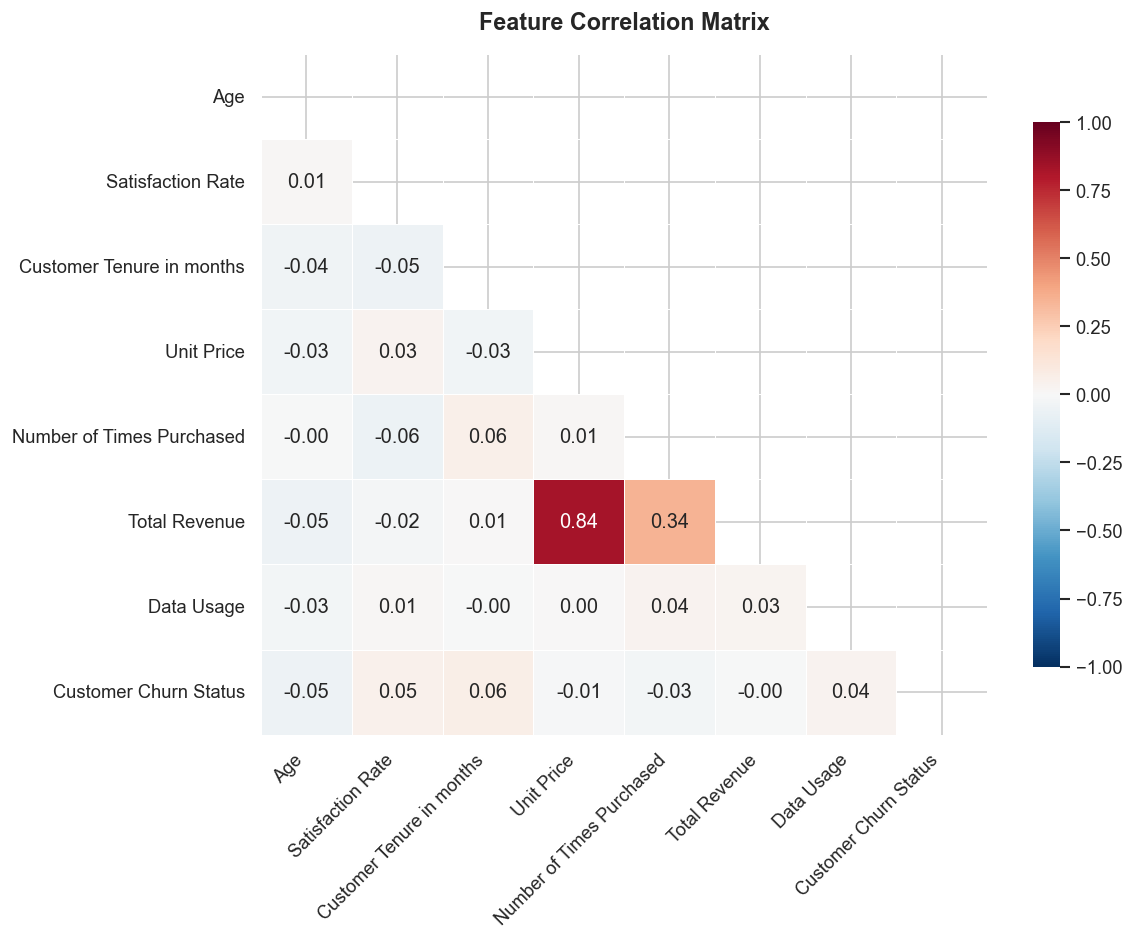


Top Correlations with Customer Churn Status:
Customer Tenure in months    0.063352
Satisfaction Rate            0.047140
Data Usage                   0.036566
Total Revenue               -0.000877
Unit Price                  -0.014986
Number of Times Purchased   -0.031024
Age                         -0.048252
Name: Customer Churn Status, dtype: float64


In [9]:
# Preparing data for correlation analysis
df_corr = df[numerical_cols].copy()
if churn_col:
    df_corr[churn_col] = df[churn_col].map({'Yes': 1, 'No': 0})

corr_matrix = df_corr.corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

if churn_col and churn_col in corr_matrix.columns:
    churn_corr = corr_matrix[churn_col].sort_values(ascending=False)
    print(f"\nTop Correlations with {churn_col}:")
    print(churn_corr[1:11])


## Step 9: Outlier Detection

I'm identifying outliers using the IQR method.

In [10]:
def detect_outliers_iqr(data, multiplier=1.5):
    """Detect outliers using IQR method."""
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - multiplier * IQR
    upper_bound = Q3 + multiplier * IQR
    return (data < lower_bound) | (data > upper_bound)

outlier_counts = {}
for col in numerical_cols[:5]:
    outliers = detect_outliers_iqr(df[col])
    outlier_counts[col] = outliers.sum()
    if outliers.sum() > 0:
        print(f"{col}: {outliers.sum()} outliers ({outliers.sum()/len(df)*100:.2f}%)")

print(f"\nTotal rows with any outlier: {df.index.isin(df[list(outlier_counts.keys())].index[detect_outliers_iqr(df[list(outlier_counts.keys())]).any(axis=1)]).sum()}")

Unit Price: 50 outliers (5.13%)

Total rows with any outlier: 50


## Step 10: Feature Engineering

I'm creating derived features to enhance model predictive power.

In [11]:
# Creating a working copy for feature engineering
df_clean = df.copy()

# Storing original column count
original_cols = list(df_clean.columns)
print(f"Original features: {len(original_cols)}")

# Encoding subscription plan as ordinal
if plan_col and plan_col in df_clean.columns:
    
    plan_map = {v: i for i, v in enumerate(sorted(df_clean[plan_col].unique()))}
    df_clean[f'{plan_col}_encoded'] = df_clean[plan_col].map(plan_map)
    print(f"Encoded {plan_col}")

# Creating interaction features
if tenure_col and tenure_col in df_clean.columns and usage_cols:
    
    if usage_cols:
        first_usage = usage_cols[0]
        if first_usage in df_clean.columns:
            df_clean[f'tenure_x_{first_usage}'] = df_clean[tenure_col] * df_clean[first_usage]
            print(f"Created interaction: tenure × {first_usage}")

# Creating revenue-per-usage ratio
if charge_cols and usage_cols:
    if charge_cols[0] in df_clean.columns and usage_cols[0] in df_clean.columns:
        df_clean['charge_per_usage'] = (df_clean[charge_cols[0]] / (df_clean[usage_cols[0]] + 1))
        print(f"Created ratio: charge per usage")

# Binning age into groups
if age_col and age_col in df_clean.columns:
    df_clean[f'{age_col}_binned'] = pd.cut(df_clean[age_col], bins=5, labels=['Very Young', 'Young', 'Middle', 'Mature', 'Senior'])
    print(f"Binned {age_col} into age groups")

print(f"\nNew features created: {len(df_clean.columns) - len(original_cols)}")
print(f"Total features: {len(df_clean.columns)}")

Original features: 17
Encoded Subscription Plan
Created interaction: tenure × Data Usage
Created ratio: charge per usage
Binned Age into age groups

New features created: 4
Total features: 21


## Step 11: Final Data Quality Check

I'm verifying the cleaned dataset is ready for modeling.

In [12]:
print("FINAL DATASET SUMMARY:")
print(f"Shape: {df_clean.shape}")
print(f"Missing values: {df_clean.isnull().sum().sum()}")
print(f"Duplicates: {df_clean.duplicated().sum()}")
print(f"\nNew numerical columns: {df_clean.select_dtypes(include=[np.number]).shape[1]}")
print(f"Categorical columns: {df_clean.select_dtypes(include=['object']).shape[1]}")
print(f"\nMemory usage: {df_clean.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

FINAL DATASET SUMMARY:
Shape: (974, 21)
Missing values: 690
Duplicates: 0

New numerical columns: 10
Categorical columns: 10

Memory usage: 0.67 MB


## Step 12: Export Cleaned Data

I'm saving the cleaned dataset for use in subsequent analyses.

In [13]:
# Exporting cleaned data for downstream analysis
df_clean.to_csv('./cleaned_data.csv', index=False)
print(f"✓ Exported cleaned data to ./cleaned_data.csv ({df_clean.shape[0]} rows, {df_clean.shape[1]} columns)")

# Verifying the export
df_test = pd.read_csv('./cleaned_data.csv')
print(f"✓ Verification: Loaded {df_test.shape[0]} rows, {df_test.shape[1]} columns")

✓ Exported cleaned data to ./cleaned_data.csv (974 rows, 21 columns)
✓ Verification: Loaded 974 rows, 21 columns


## What I Took Away from the EDA

So after digging through the MTN Nigeria dataset (974 customers, 17 raw features), here's where I landed:

The churn rate sits at 29.2%, which is high but workable. 284 customers left, and the reasons they gave are a mix of things MTN can and can't control: relocation is unavoidable, but "better offers from competitors" and "costly data plans" are absolutely fixable. That tells me pricing and competitive positioning should be central to any retention strategy.

Satisfaction Rate jumped out as a feature I expect to matter a lot downstream. It's a clean 1-to-5 scale, and the Customer Review column (Poor/Fair/Good/Excellent) maps directly to it. Dissatisfied customers are the low-hanging fruit for retention teams.

The data itself was surprisingly clean. No missing values at all, except "Reasons for Churn" which is only populated for churners (as you'd expect). No duplicates either. Tenure spans 1 to 60 months with a fairly even distribution, so we've got a nice range to work with.

I added four engineered features: a tenure-times-usage interaction, a revenue-per-usage ratio, age bins, and an encoded subscription plan. None of the individual correlations with churn are strong (all under 0.1), which honestly suggests the interesting patterns will show up in multivariate combinations, not simple linear relationships. That's exactly what the logistic regression in notebook 03 is for.

The cleaned dataset (21 features) is ready for A/B test simulation and churn modeling.